# **02. Neighborhood & Zoning Anlaysis**


### **Introduction**



### **Project Objectives**

**1. What impact does geographic location have on property values in Ames, Iowa?**

**2. How does the different type of zoning affect property prices in Ames, Iowa?**


#### **Ames Housing Data Description**

The data was collected by De Cock where 81 dimensions were recorded for 1460 properties in Ames IA.

Brief description of columns:

**1. Identification**
- **Id:** Property ID (unique identifier)
- **SalePrice:** Target variable — final selling price
- **GrLivArea:** Above-ground living area
- **YrSold:** Year sold
- **MSZoning:** Zoning classification
- **Neighborhood:** Physical location within Ames

**This dataset contains information on individual house sales in Ames, Iowa, from 2006 to 2010, including location, zone informations etc., and sales data.**


## **1. Loading Dataset**

In [1]:
import sys
import importlib
sys.path.append("..")

from src.utilis import *
#importlib.reload(utilis)


In [2]:
# define path
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "raw")
processed_path = parent_path.joinpath("data", "processed")

org_files = []
display_md("**Original Files :**")
for file in data_path.rglob("*.csv"):
    org_files.append(file)
    print(org_files.index(file), " ", file.name)

pro_files = []
display_md("**Cleaned Files :**")
for fle in processed_path.rglob("*"):
    pro_files.append(fle)
    print(pro_files.index(fle), " ", fle.name)


**Original Files :**

0   sample_submission.csv
1   test.csv
2   train.csv


**Cleaned Files :**

0   .gitkeep
1   test_cleaned.csv
2   train_cleaned.csv


In [3]:
display_md("Loading Original Datasets :")

# Load original data 
train_org = pd.read_csv(org_files[2])
test_org = pd.read_csv(org_files[1])    

# standardize the column names
train_org.columns = train_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
test_org.columns = test_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

# Drop rows where YrSold < YearRemodAdd
#train_original = train_org[train_org['YrSold'] >= train_org['YearRemodAdd']]

display_md("**Original Training and Testing data Shape**")

print("Original Training data shape: ", train_org.shape)
print("Original Testing data shape: ", test_org.shape)

display_md("**Duplicate Rows in  Data**")

print("Number of duplicate rows in training data: ", train_org.duplicated().sum())
print("Number of duplicate rows in testing data ", test_org.duplicated().sum())


Loading Original Datasets :

**Original Training and Testing data Shape**

Original Training data shape:  (1460, 81)
Original Testing data shape:  (1459, 80)


**Duplicate Rows in  Data**

Number of duplicate rows in training data:  0
Number of duplicate rows in testing data  0


In [4]:
# Features selected for neighborhhod and zoning analysis
df_train = train_org[['Id', 'GrLivArea', 'Neighborhood', 'MSZoning', 'YrSold', 'SalePrice']].copy()
df_test = test_org[['Id', 'GrLivArea', 'Neighborhood', 'MSZoning', 'YrSold']].copy()


In [5]:
data_df = datatype_df(df_train)
display(data_df)


,Dtype,nunique,unique,missing_value
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0
GrLivArea,int64,861,"[1710, 1262, 1786, 1717, 2198, 1362, 1694, 209...",0
Neighborhood,object,25,"[CollgCr, Veenker, Crawfor, NoRidge, Mitchel, ...",0
MSZoning,object,5,"[RL, RM, C (all), FV, RH]",0
YrSold,int64,5,"[2008, 2007, 2006, 2009, 2010]",0
SalePrice,int64,663,"[208500, 181500, 223500, 140000, 250000, 14300...",0


### **Exploratory Data Analysis Using Visualizations**

Let's investigate the key questions outlined in the project objectives using charts and visualizations.


__`Question 1.` What impact does geographic location have on property values in Ames, Iowa?__

Location is an important factor to decide house prices. In this study, we will examine how neighborhoods affect home values in Ames & whether the link between house size and price changes depending on the neighborhood.


We will examine neighborhood sales from 2006–2010 to identify areas with unusually high sales and potential differences during the 2007–2009 financial crisis.


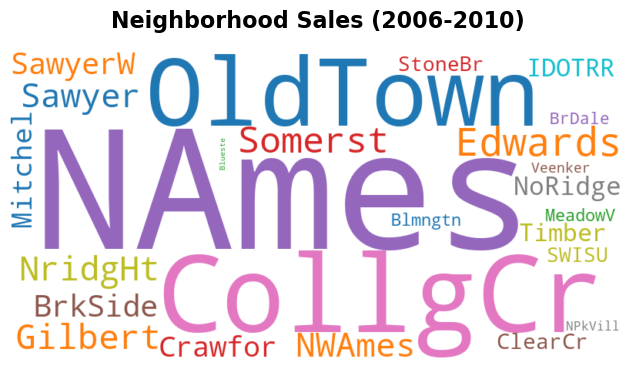

**Finding :** This word cloud shows which neighborhoods in Ames, Iowa had more houses sold compared to others. North Ames (NAmes) had the highest sales, followed by College Creek (CollgCr), Old Town (OldTown), and Edwards. The fewest sales were in Veenker, Bluestem, and Northpark Villa (NPkvill). This suggests that neighborhoods with more sales during this time may have been more affected by the financial crisis than those with fewer sales.

In [6]:
new_df = df_train.copy()
from wordcloud import WordCloud, STOPWORDS
# Filter for houses sold between 2006 and 2010
sales_period = new_df[new_df['YrSold'].between(2006, 2010)]

# Count sales per neighborhood
neighborhood_counts = sales_period['Neighborhood'].value_counts()

# Convert counts into a dictionary for weighting
ext = " ".join(sales_period['Neighborhood'])

# Generate word cloud (size of word = number of sales)
wordcloud = WordCloud(width=800, height=400, background_color="white",
                      colormap="tab10", max_words=100,
                      contour_color="k", contour_width=2).generate(ext)

# Display the word cloud
plt.figure(figsize=(8,4))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Neighborhood Sales (2006-2010)", fontsize=16, fontweight='bold', y=1.05)
plt.show()

display_md("**Finding :** This word cloud shows which neighborhoods in Ames, Iowa had more houses sold compared to others. North Ames (NAmes) had the highest sales, followed by College Creek (CollgCr), Old Town (OldTown), and Edwards. The fewest sales were in Veenker, Bluestem, and Northpark Villa (NPkvill). This suggests that neighborhoods with more sales during this time may have been more affected by the financial crisis than those with fewer sales.")


**1.1. Neighborhood and House Prices**

The dataset includes a feature called `Neighborhood`, which shows where each house is located. There are 25 neighborhoods in total, and we expect prices to vary between them. We demonstrate this with a bar plot.


,Neighborhood,avg_sales,relative_pct
0,NoRidge,335295.32,7.29
1,NridgHt,316270.62,14.17
2,StoneBr,310499.00,20.92
3,Timber,242247.45,26.19
4,Veenker,238772.73,31.38
5,Somerst,225379.84,36.28
6,ClearCr,212565.43,40.90


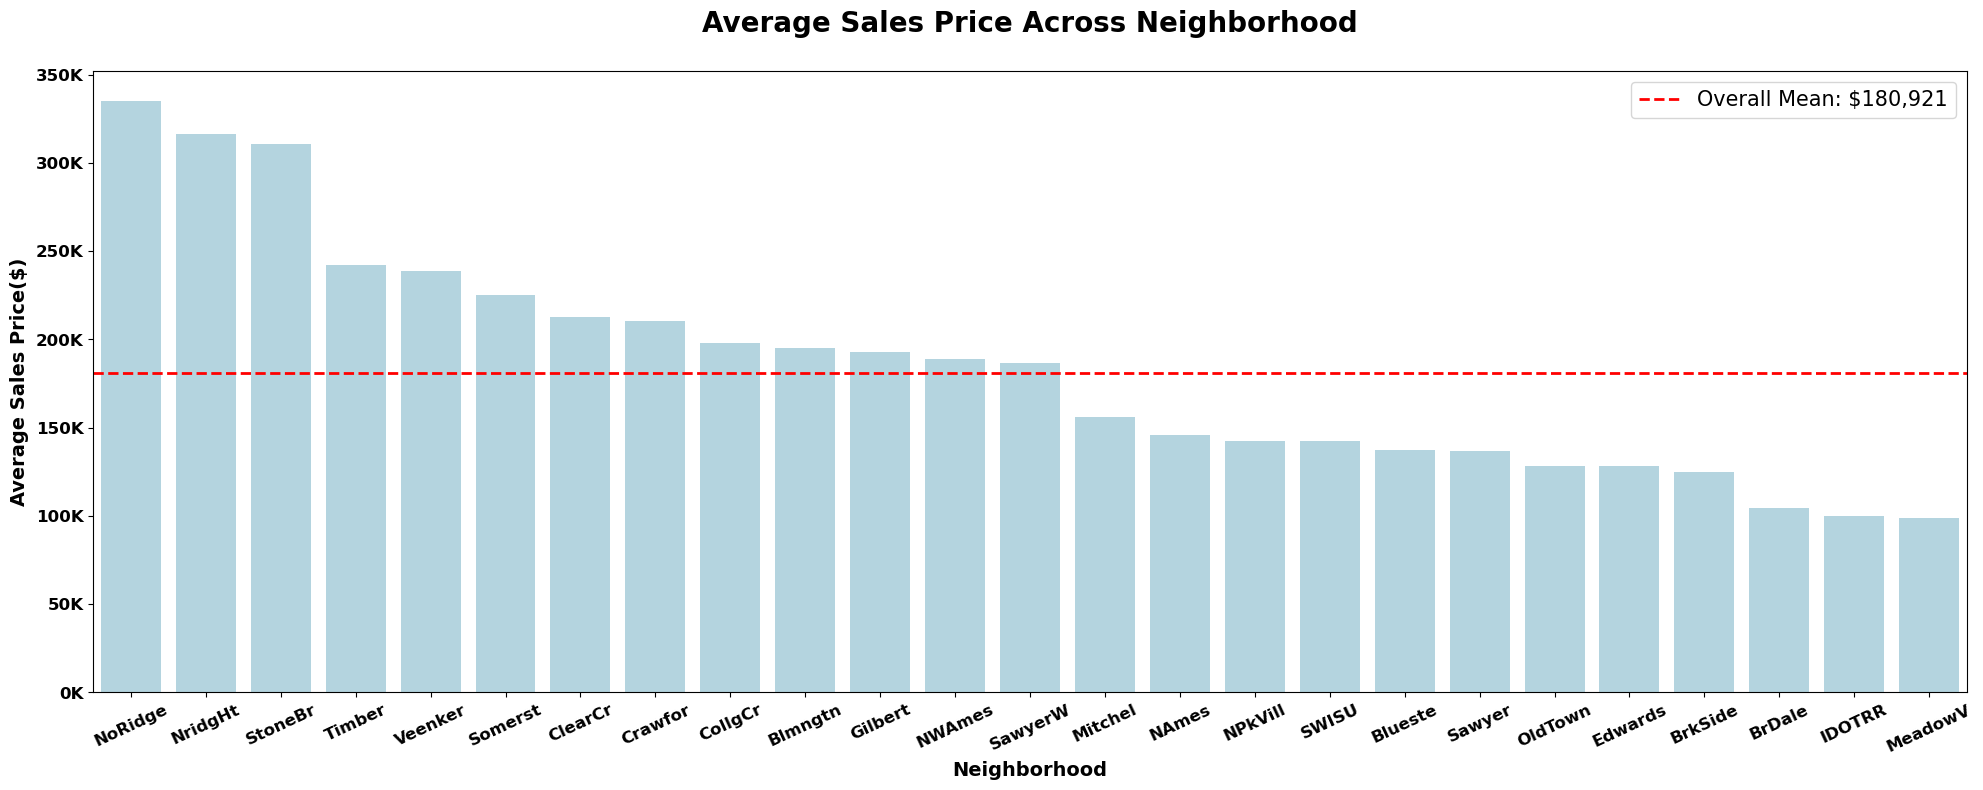

Average house prices vary across neighborhoods. Some neighborhoods exhibit notably higher average sale prices, which may suggest that it is located in a more desirable or affluent neighborhood . **Northridge has the highest average price, about three times that of Meadow Village, the lowest-priced neighborhood. Additionally, the top seven neighborhoods contribute about 41% of total property sales value, highlighting their significant contribution to the overall housing market.**

In [33]:
# Aggregate average sale price of house by neighborhood

avgsales_df = (
    new_df.groupby(['Neighborhood'])
    .agg(
        avg_sales = ("SalePrice", 'mean')
    )
    .sort_values(by='avg_sales',ascending=False)
    .reset_index()
)
avgsales_df = avgsales_df.assign(relative_pct = 100 *avgsales_df['avg_sales'].cumsum()/avgsales_df['avg_sales'].sum())
display(avgsales_df[:7])

# Visualization
fig, ax = plt.subplots(figsize=(20, 8))
# bar plot
sns.barplot(
    data=avgsales_df, 
    x='Neighborhood', y='avg_sales',
    color='lightblue', ax=ax)

# Overall mean of saleprice
overall_mean = new_df['SalePrice'].mean()
ax.axhline(overall_mean,
           color='r',
           lw=2, ls='--',
           label=f'Overall Mean: ${overall_mean:,.0f}')

ax.set_title("Average Sales Price Across Neighborhood", fontsize=20, fontweight='bold', y=1.05)
ax.set_xlabel("Neighborhood", fontsize=14, fontweight='bold', labelpad=5)
ax.set_ylabel("Average Sales Price($)", fontsize=14, fontweight='bold', labelpad=5)
ax.tick_params(axis='x', rotation=25)
ax.set_yticklabels([f"{y/1000:.0f}K" for y in ax.get_yticks()], fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontdict={'size':12, 'weight':'bold'})
ax.legend(fontsize=15)

plt.tight_layout()
plt.show()

display_md("Average house prices vary across neighborhoods. Some neighborhoods exhibit notably higher average sale prices, which may suggest that it is located in a more desirable or affluent neighborhood . **Northridge has the highest average price, about three times that of Meadow Village, the lowest-priced neighborhood. Additionally, the top seven neighborhoods contribute about 41% of total property sales value, highlighting their significant contribution to the overall housing market.**")



To see if the different house prices can be actually explained by neighborhoods, we create a dendrogram and examine if the houses in the same neighborhood form a cluster.
We use a dendrogram on `SalePrice` to identify clusters of house prices across neighborhoods.


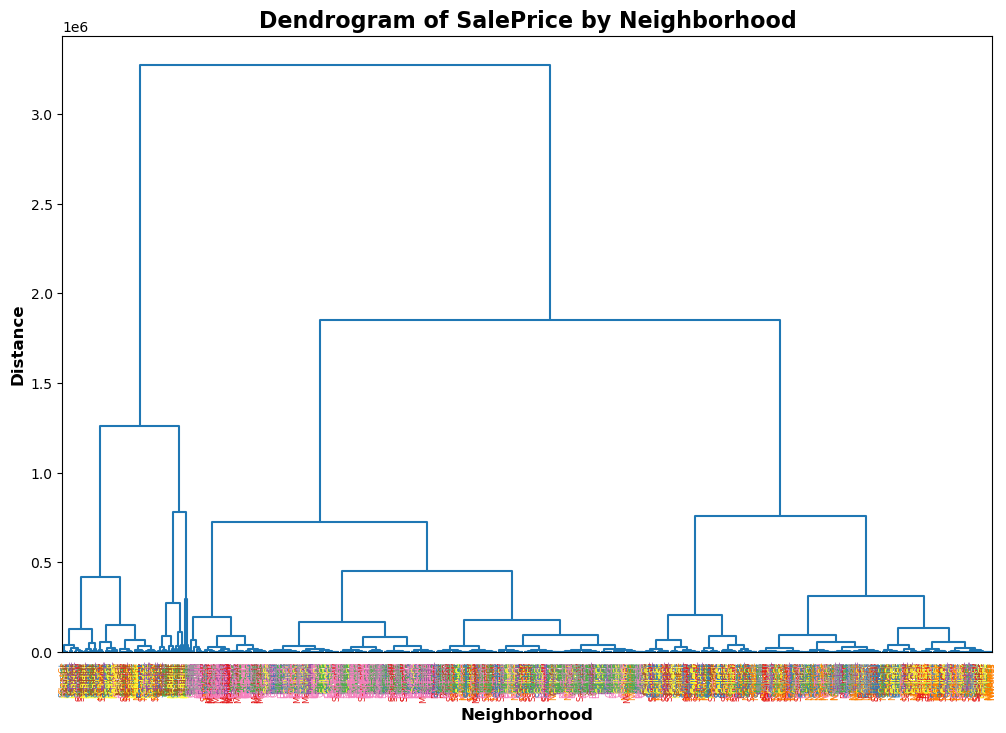

**Insight** :Once the clusters are formed, we display leaves and color them based on the neighborhood. Even though there are many houses, we just check if the same colors group together. They do--- yellow on the left, pink in the middle, green on the right and blue further right. **This indicate that houses within each neighborhood are similar to each other in terms of their sale prices.**

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import LabelEncoder

# Select SalePrice and Neighborhood
prices = new_df[["SalePrice", "Neighborhood"]]

# Encode neighborhoods into numeric labels for coloring
le = LabelEncoder()
prices["NeighborhoodCode"] = le.fit_transform(prices["Neighborhood"])

# Perform hierarchical clustering on SalePrice only
linked = linkage(prices[["SalePrice"]], method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dend = dendrogram(
    linked,
    labels=prices["Neighborhood"].values,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=0  # ensures branches are colored
)

# Color the leaf labels by neighborhood
ax = plt.gca()
for lbl in ax.get_xticklabels():
    neighborhood = lbl.get_text()
    code = le.transform([neighborhood])[0]
    # Assign colors based on neighborhood code
    colors = plt.cm.Set1(code % 10)  # cycle through 20 distinct colors
    lbl.set_color(colors)

plt.title("Dendrogram of SalePrice by Neighborhood", fontsize=16, fontweight='bold')
plt.xlabel("Neighborhood", fontsize=12, fontweight='bold')
plt.ylabel("Distance", fontsize=12, fontweight='bold')
plt.show()

display_md("**Insight** :Once the clusters are formed, we display leaves and color them based on the neighborhood. Even though there are many houses, we just check if the same colors group together. They do--- yellow on the left, pink in the middle, green on the right and blue further right. **This indicate that houses within each neighborhood are similar to each other in terms of their sale prices.**")



Before examining how neighborhood affects the link between house size and sale price, will first categorize SalePrice into discrete ranges. Turning it into a factor will make each price bracket clearer, and to explore this, we visualize the distribution with a bar plot.

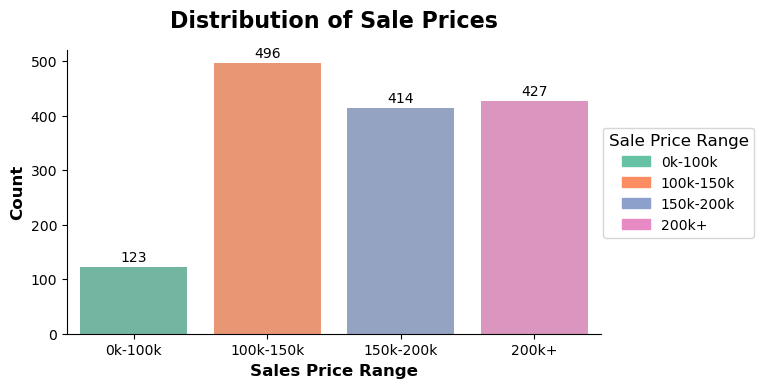

**Finding** :The chart shows four price categories, with most properties falling in the 100k-150k range, followed closely by 200k+. The 0-100k bracket has the fewest properties, highlighting a smaller market segment of propertied for lower‑priced homes.

In [9]:
# Define bins and labels
bins = [-float("inf"), 100000, 150000, 200000, float("inf")]
labels = ["0k-100k", "100k-150k", "150k-200k", "200k+"]

# Create the new categorical column
new_df["SalePriceRange"] = pd.cut(new_df["SalePrice"], 
                                  bins=bins, 
                                  labels=labels)

# Count values for each category
counts = new_df['SalePriceRange'].value_counts().sort_index()

# Create bar plot
plt.figure(figsize=(8,4))
sns.barplot(
    x=counts.index,
    y=counts.values,
    palette="Set2"
)

# Add count labels above bars
for i, val in enumerate(counts.values):
    plt.text(i, val + 5, str(val), ha='center', va='bottom')

# Add legend with custom colors
handles = [plt.Rectangle((0,0),1, 1, color=color)
           for color in sns.color_palette("Set2", n_colors = len(counts.index))]
plt.legend(handles, counts.index, title="Sale Price Range", title_fontsize=12, fontsize=10, loc='upper right', bbox_to_anchor=(1.30, 0.75), fancybox=True)

# Titles and labels
plt.title("Distribution of Sale Prices", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Sales Price Range",fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')
sns.despine(right=True, top=True)

# Show plot
plt.tight_layout()
plt.show()

display_md("**Finding** :The chart shows four price categories, with most properties falling in the 100k-150k range, followed closely by 200k+. The 0-100k bracket has the fewest properties, highlighting a smaller market segment of propertied for lower‑priced homes.")



Explore the distribution of house size across different `SalePriceRange` categories. Visualize the trend through boxplot and add linear trend line to show the relationship between living arra size and sale price range.


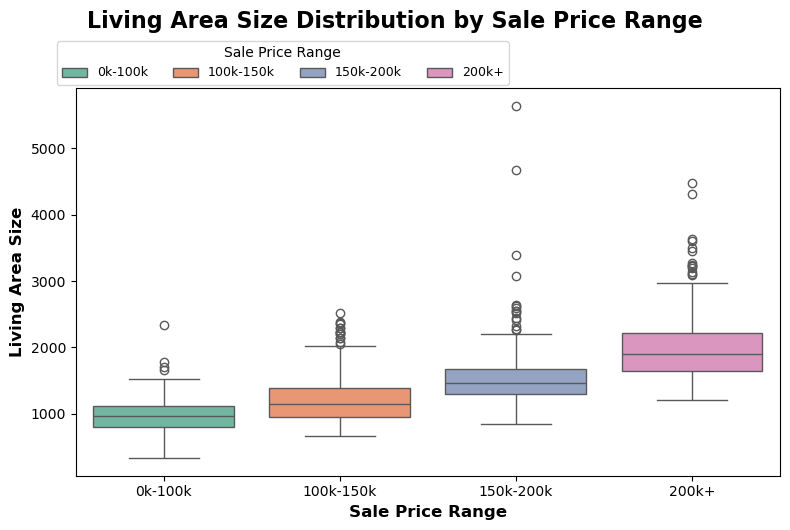

The boxplot, living area size Distribution by Sale Price Range, highlights the link between living area size and property price. **It shows a clear upward trend: as sale price ranges increase, house size also rises.** In particular, 0–100k category has the smallest median and a compact distribution, reflecting that lower-priced homes typically have smaller living spaces. while the 100k–150k and 150k–200k ranges show bigger and more varied living spaces. Properties in the 200k+ category stand out with the highest median and broadest spread, this indicates a significant variation in house sizes within this higher price category, which includes properties with significantly larger house size. but the presence of outliers shows that square foot alone does not determine property value. Other factors also influence pricing, and a fuller analysis would need to consider them.

In [13]:
import matplotlib.patches as mpatches


# Plot
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(
    data=new_df,
    x="SalePriceRange",
    y="GrLivArea",
    hue="SalePriceRange",
    #order=order,
    palette="Set2",
    legend=True, 
    ax=ax
)

fig.suptitle("Living Area Size Distribution by Sale Price Range",
          fontsize=16, fontweight="bold", y=1.05) 
ax.set_xlabel("Sale Price Range", fontsize=12, fontweight='bold')
ax.set_ylabel("Living Area Size", fontsize=12, fontweight='bold')
fig.legend(title='Sale Price Range', bbox_to_anchor=(0.65, 1), ncol=4, title_fontsize=10, fontsize=9)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

display_md("The boxplot, living area size Distribution by Sale Price Range, highlights the link between living area size and property price. **It shows a clear upward trend: as sale price ranges increase, house size also rises.** In particular, 0–100k category has the smallest median and a compact distribution, reflecting that lower-priced homes typically have smaller living spaces. while the 100k–150k and 150k–200k ranges show bigger and more varied living spaces. Properties in the 200k+ category stand out with the highest median and broadest spread, this indicates a significant variation in house sizes within this higher price category, which includes properties with significantly larger house size. but the presence of outliers shows that square foot alone does not determine property value. Other factors also influence pricing, and a fuller analysis would need to consider them.")


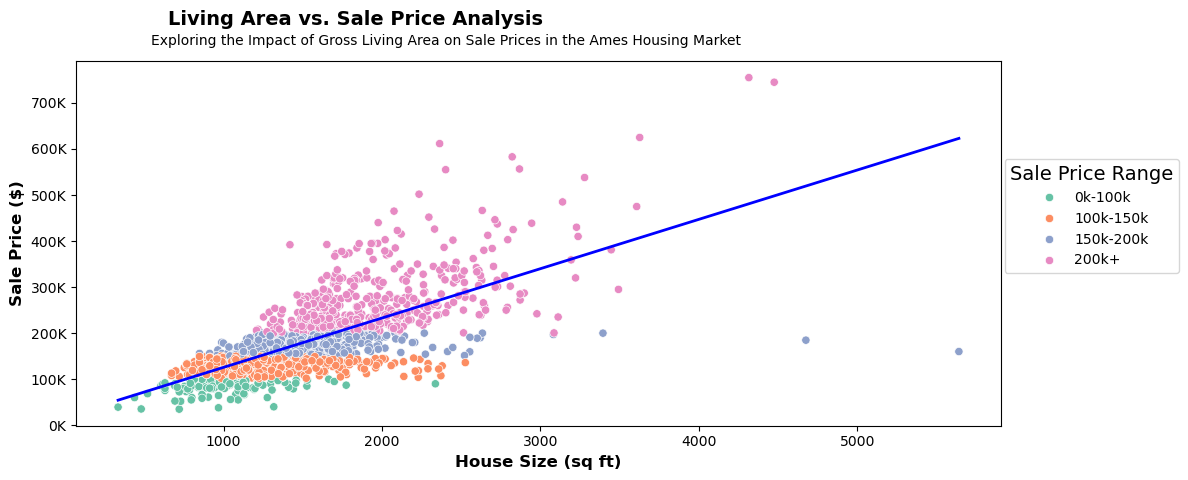

The scatter plot shows that larger living areas generally correspond to higher sale prices, with properties over 4,000 square feet standing out as outliers. While size influences house price, these exceptions(outliers) suggest other factors also play a role. The color-coded layers create a clear stratification of price ranges across different living area sizes.

In [34]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12,5))

# Scatter plot 
sns.scatterplot(
    data=new_df,
    x="GrLivArea",
    y="SalePrice",
    hue="SalePriceRange",
    palette="Set2",
    ax=ax
)

# Add trend line for relationship of house size and price
sns.regplot(
    data=new_df,
    x='GrLivArea', y='SalePrice',
    scatter=False, ci=None,
    color='b', line_kws={'ls':'-', 'lw':2},
    ax=ax
)

# Titles and labels and legend
ax.legend(title='Sale Price Range', title_fontsize=14, loc='upper right', bbox_to_anchor=(1.2, 0.75), fancybox=True)
fig.suptitle("Living Area vs. Sale Price Analysis", fontsize=14, fontweight="bold", y=0.95, x=0.3)
ax.set_title("Exploring the Impact of Gross Living Area on Sale Prices in the Ames Housing Market", fontsize=10, y=1.02, x=0.4)
ax.set_xlabel("House Size (sq ft)", fontsize=12, fontweight='bold')
ax.set_ylabel("Sale Price ($)", fontsize=12, fontweight='bold')


# Format y-axis 
ax.set_yticklabels([f"{y/1000:.0f}K" for y in ax.get_yticks()])

# Adjust layout
plt.tight_layout()
plt.show()

display_md("The scatter plot shows that larger living areas generally correspond to higher sale prices, with properties over 4,000 square feet standing out as outliers. While size influences house price, these exceptions(outliers) suggest other factors also play a role. The color-coded layers create a clear stratification of price ranges across different living area sizes.")

